In [35]:
import numpy as np
import matplotlib.pyplot as plt

def ObtenerClasesEnStrings(matriz_Y):
    N_muestras = matriz_Y.shape[1] 
    clases_str = np.empty(N_muestras, dtype='<U5') # Pre-asignar espacio para "Perro"
    #Recorremos todas las columnas de nuestra matriz Y
    for i in range(N_muestras):
        logit_gato = matriz_Y[0, i] 
        logit_perro = matriz_Y[1, i] 
        #Comparamos donde esta el digito de mayor valor si en la primer fila o la segunda
        if logit_gato >= logit_perro:
            clases_str[i] = "Gato" #Si está en la primera, asignamos Gato
        else:
            clases_str[i] = "Perro" #Si está en la segunda, asignamos Perro
            
    return clases_str

def GenerarMatrizDeConfusion(W, Xval, Yval):
    """Genera la Matriz de Confusión y calcula la Accuracy (Exactitud) y la precisión para la matriz de pesos W
    Parámetros:
          W : Matriz de pesos (2 x 1536).
         Xval : Matriz de embeddings de validación (1536 x n_val).
         Yval : Matriz de targets de validación (2 x n_val). 
    Retorna:
        matriz_de_confusion: de 2x2 en el orden [[TP, FP], [FN, TN]].
        accuracy, precision (float): La exactitud y precision general del clasificador."""
                                                                         
    # Elegiremos para nuestras clases la siguiente convención: Gato (0) = Negativo, Perro (1) = Positivo.

    Ypred = W @ Xval #Calculamos Ypred (nuestra matriz de targets con los valores predichos)
    Y_verd= ObtenerClasesEnStrings(Yval) #Encontramos la CLASE REAL de Gatos y Perros recorriendo todas las columnas por ambas filas, donde
                                       #si nos encontramos con [1,0]^T clasificamos como (0: Gato) y si nos encontramos [0,1]^T  clasificamos como (1: Perro)
                                       #Y guardamos todo esto en un aarray

    Y_pred= ObtenerClasesEnStrings(Ypred) #Hacemos lo mismo que en el paso anterior, pero obteniendo la CLASE PREDICHA. En este caso a diferencia de antes, los logits 
                                  #NO son puros ([0,1]^T o [1,0]^T), pero de todas formas se va a hacer la misma comparación, devolviendo la etiqueta que corresponda
                                  #segun la ubicación de los logits

    # Inicializamos contadores
    TP = 0 # True Positives Verdadero P (1), Predicho P (1)
    FP = 0 # False Positives: Verdadero N (0), Predicho P (1)
    TN = 0 # True Negatives: Verdadero N (0), Predicho N (0)
    FN = 0 # False Negatives: Verdadero P (1), Predicho N (0)
    
    n_val = Xval.shape[1] #Obtenemos la cantidad de muestras totales entre perros y gatos

    for i in range(n_val):
        true_label = Y_verd[i] 
        pred_label = Y_pred[i]
        
        # Estamos en la clase positiva (PERRO) y queremos ver como fue la clasificación
        if true_label == "Perro": 
            if pred_label == "Perro": #Si lo real coincide con lo predicho, entonces sumamos 1 a TP (Lo clasificamos como perro y efectivamente era perro)
                TP += 1 
            else:
                FN += 1  #Si no sumamos 1 a FN (Dijimos que era Gato cuando en realidad era Perro)
        # Estamos en la clase Negativa (GATO) y queremos ver como fue la clasificación
        else: 
            if pred_label == "Gato": #Lo mismo que antes pero con gatos
                TN += 1 
            else:
                FP += 1 # Si lo clasificamos como Perro y en realidad era gato.

    matriz_de_confusion = np.array([[TP, FP],
                                 [FN, TN]])
    
    total_muestras = n_val #Total de muestras= TP+TN+FP+FN
    accuracy = (TP + TN) / total_muestras #Porcentaja de clasificaciones correctas.
    
    if (TP + FP) == 0:
        precision = 0.0
    else:
        precision = TP / (TP + FP) #De las instancias clasificadas como positivas, cuántas lo son realemente.
        
    return matriz_de_confusion, accuracy, precision


def muestraDeNelementos(A,n):
    """
    Devuelve una muestra de n elementos. n/2 gatos y n/2 perros
    """
    m=round(int(n*0.76))

    n=int(n/2)

    primeras_n_cols = A[:, :n]
    ultimas_n_cols = A[:, -n:]
    res=np.concatenate((primeras_n_cols,ultimas_n_cols),axis=1)


    res = res[:m, :]
    return res


def muestraDeNelementos_Y(A,n):
    """
    Devuelve una muestra de n elementos. n/2 gatos y n/2 perros
    """

    n=int(n/2)
    
    primeras_n_cols = A[:, :n]
    ultimas_n_cols = A[:, -n:]
    res=np.concatenate((primeras_n_cols,ultimas_n_cols),axis=1)

    return res


def plot_confusion_matrix(matriz_conf, accuracy, precision, metodo_W, n, ax):
    """
    Genera un mapa de calor visual de la matriz de confusión sobre un subplot (ax)
    """

    TP, FP = matriz_conf[0, 0], matriz_conf[0, 1]
    FN, TN = matriz_conf[1, 0], matriz_conf[1, 1]

    y_labels = ['Perro', 'Gato']
    x_labels = ['Perro', 'Gato']

    # ✅ Usar el AXIS en vez de plt
    if 'sns' in globals():
        sns.heatmap(
            matriz_conf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=x_labels,
            yticklabels=y_labels,
            linewidths=0.5,
            linecolor='black',
            cbar=False,
            ax=ax
        )
    else:
        ax.imshow(matriz_conf, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_xticks(np.arange(len(x_labels)))
        ax.set_yticks(np.arange(len(y_labels)))
        ax.set_xticklabels(x_labels)
        ax.set_yticklabels(y_labels)

        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(matriz_conf[i, j]),
                        ha='center', va='center', color='black', fontsize=12)

    ax.set_title(f'{metodo_W} ({n} muestras)')
    ax.set_xlabel(f'Accuracy: {accuracy:.4f}\nPrecision: {precision:.4f}')
    ax.set_ylabel('Clase Predicha')


#Funciones de Numpy para hacer la comparativa

def pinv_numpy_qr(X, Y):
    Q, R = np.linalg.qr(X)  
    W = np.linalg.solve(R, Q.T @ Y)
    return W.T

def pinv_numpy_svd(X, Y, tol=1e-12):
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
        
    S_inv = np.array([1/s if s > tol else 0 for s in S])
    
    W = (Vt.T * S_inv) @ (U.T @ Y)
    return W.T

def pinv_numpy_cholesky(X, Y):
    XtX = X.T @ X
    XtY = X.T @ Y

    R = np.linalg.cholesky(XtX)

    z = np.linalg.solve(R, XtY)

    W = np.linalg.solve(R.T, z)

    return W.T

In [36]:
from re_alc import cargarDataset, pinvEcuacionesNormales, pinvSVD, pinvHouseHolder, pinvGramSchmidt, svd_reducida_modificada,QR_con_GS,QR_con_HH
import time
Xt_o,Yt_o,Xv_o,Yv_o=cargarDataset('dataset/')
tam_muestra=[10,20,50,100,120,150]#,170,200,250]
t_ejecucion_HH=[]
t_ejecucion_SVD=[]
t_ejecucion_GS=[]
t_ejecucion_CH=[]

np_ejecucion_QR=[]
np_ejecucion_SVD=[]
np_ejecucion_CH=[]
metodos_numpy=[]
total_matriz=[] #Datos para matriz de confusión de toda la muestra
total_dif_W=[] #Guarda la diferncia W-W_numpy

for j in range(0,len(tam_muestra),1):
    
    muestra=tam_muestra[j]
    
    Xt=(muestraDeNelementos(Xt_o,muestra))
    Yt=(muestraDeNelementos_Y(Yt_o,muestra))
    Xv=(muestraDeNelementos(Xv_o,muestra))
    Yv=(muestraDeNelementos_Y(Yv_o,muestra))

    #Entrena matrices con distintos métodos
    XtT = Xt.T
    p, n = XtT.shape  
    
    #Funciones TP
    inicio= time.time()  
    Q, R = QR_con_HH(XtT)
    W_hh = pinvHouseHolder(Q,R,Yt)
    fin= time.time()
    ejecucion=fin - inicio
    t_ejecucion_HH.append(ejecucion)
    
    inicio= time.time() 
    U,S,V=svd_reducida_modificada(Xt)
    W_SVD = pinvSVD(U,S,V,Yt)
    fin= time.time()
    ejecucion=fin - inicio
    t_ejecucion_SVD.append(ejecucion)
    
    inicio= time.time() 
    Q, R = QR_con_GS(XtT)
    W_GS=pinvGramSchmidt(Q,R,Yt)
    fin= time.time()
    ejecucion=fin - inicio
    t_ejecucion_GS.append(ejecucion)
    
    inicio= time.time()
    W_CH=pinvEcuacionesNormales(Xt,Yt)
    fin= time.time()
    ejecucion=fin - inicio
    t_ejecucion_CH.append(ejecucion)

    #Usamos funciones numpy
    inicio= time.time()  
    N_W_hh = pinv_numpy_qr(Xt.T,Yt.T)
    fin= time.time()
    ejecucion=fin - inicio
    np_ejecucion_QR.append(ejecucion)

    inicio= time.time()  
    N_W_SVD = pinv_numpy_svd(Xt.T,Yt.T)    
    fin= time.time()
    ejecucion=fin - inicio
    np_ejecucion_SVD.append(ejecucion)

    inicio= time.time()  
    N_W_CH = pinv_numpy_cholesky(Xt.T,Yt.T)   
    fin= time.time()
    ejecucion=fin - inicio
    np_ejecucion_CH.append(ejecucion)

    

    metodos=[W_hh,W_SVD,W_GS,W_CH]
    metodos_numpy=[N_W_hh,N_W_SVD,N_W_hh,N_W_CH] #comparo HH t GS con QR de numpy
    nombre_metodo=['Householder','SVD','Gram-Schmidt','Cholesky']
    diferencia_W=[W_hh-N_W_hh,W_SVD-N_W_SVD,W_GS-N_W_hh,W_CH-N_W_CH]
    total_dif_W.append(diferencia_W)
    #Genera matriz de confusión por tamaño de muestra y metodo
    
    #Cada elemento de base matriz es de la forma : (matriz_conf,accuracy,precision,metodo,tamaño muestra)
    base_matriz=[]    
    for k in range(0,len(metodos),1):        
        matr_conf, acc, prec = GenerarMatrizDeConfusion(metodos[k], Xv,Yv)          
        datos_matriz=(matr_conf,acc,prec,nombre_metodo[k],tam_muestra[j])
        base_matriz.append(datos_matriz)
    total_matriz.append(base_matriz)

        



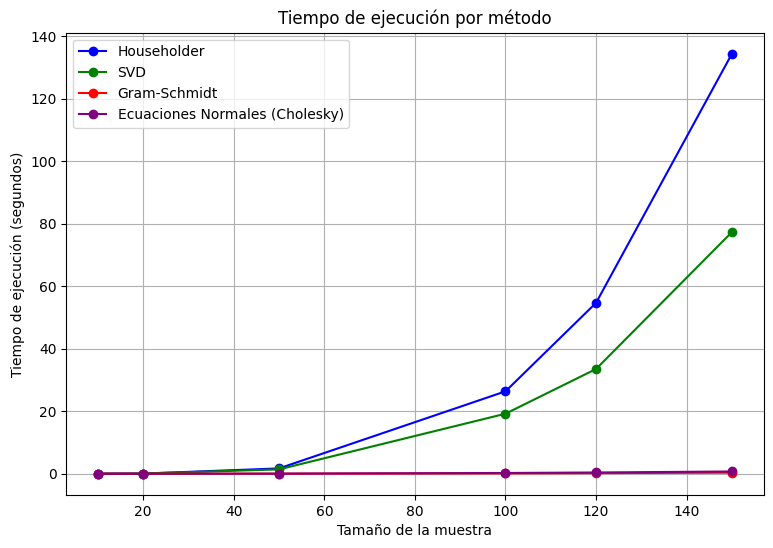

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.plot(tam_muestra, t_ejecucion_HH, marker='o', label='Householder', color='blue')
plt.plot(tam_muestra, t_ejecucion_SVD, marker='o', label='SVD', color='green')
plt.plot(tam_muestra, t_ejecucion_GS, marker='o', label='Gram-Schmidt', color='red')
plt.plot(tam_muestra, t_ejecucion_CH, marker='o', label='Ecuaciones Normales (Cholesky)', color='purple')

plt.title("Tiempo de ejecución por método")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.legend()
plt.grid(True)

plt.show()



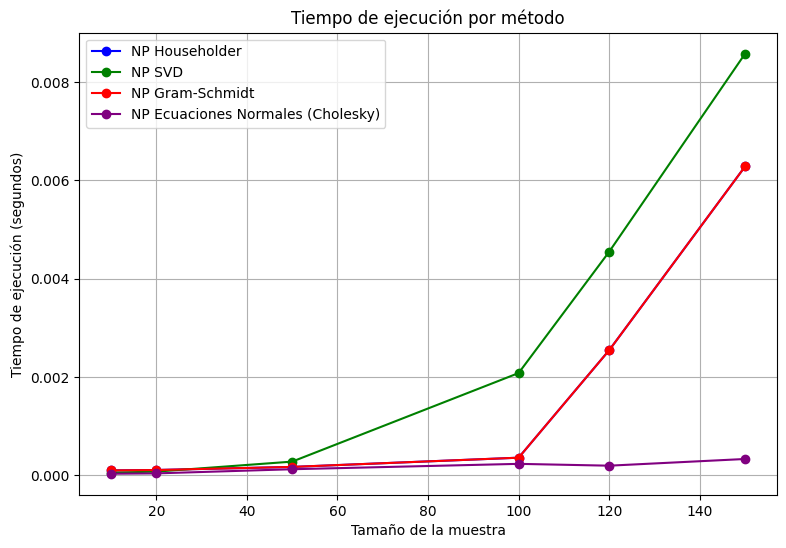

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.plot(tam_muestra, np_ejecucion_QR, marker='o', label='NP Householder', color='blue')
plt.plot(tam_muestra, np_ejecucion_SVD,marker='o', label='NP SVD', color='green')
plt.plot(tam_muestra, np_ejecucion_QR, marker='o', label='NP Gram-Schmidt', color='red')
plt.plot(tam_muestra, np_ejecucion_CH, marker='o', label='NP Ecuaciones Normales (Cholesky)', color='purple')

plt.title("Tiempo de ejecución por método")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.legend()
plt.grid(True)

plt.show()


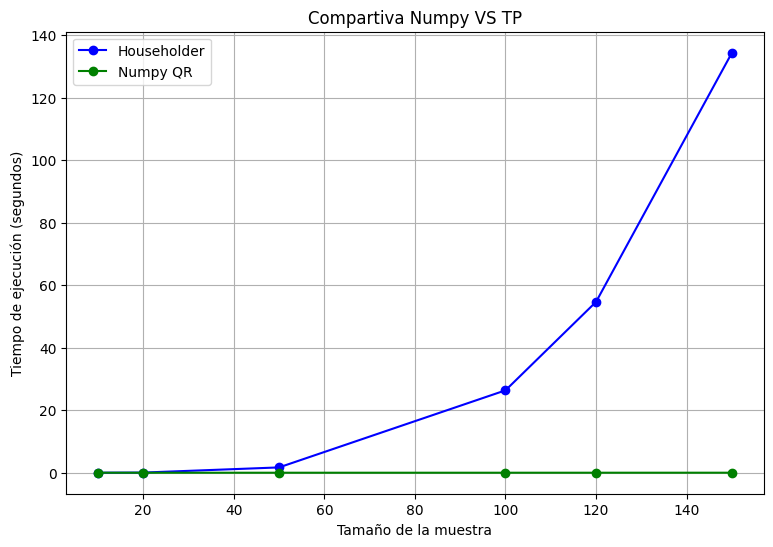

In [39]:


plt.figure(figsize=(9,6))

plt.plot(tam_muestra, t_ejecucion_HH, marker='o', label='Householder', color='blue')
plt.plot(tam_muestra, np_ejecucion_QR, marker='o', label='Numpy QR', color='green')

plt.title("Compartiva Numpy VS TP")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.legend()
plt.grid(True)

plt.show()


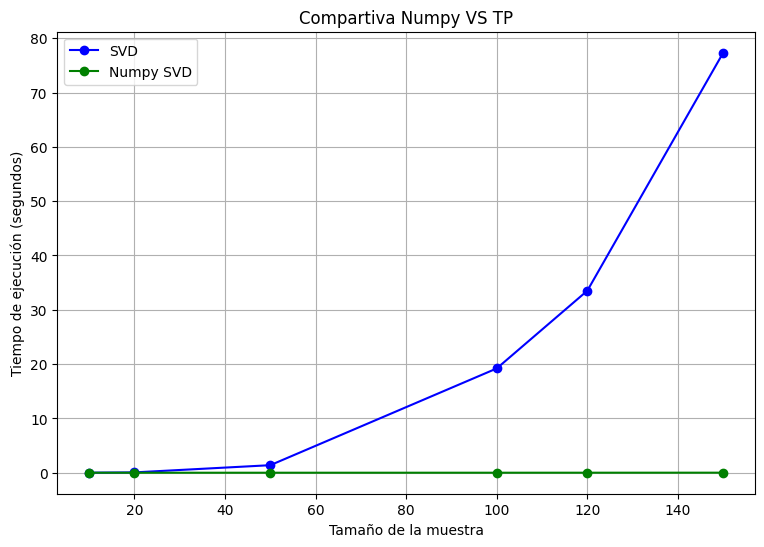

In [40]:
plt.figure(figsize=(9,6))

plt.plot(tam_muestra, t_ejecucion_SVD, marker='o', label='SVD', color='blue')
plt.plot(tam_muestra, np_ejecucion_SVD, marker='o', label='Numpy SVD', color='green')

plt.title("Compartiva Numpy VS TP")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.legend()
plt.grid(True)

plt.show()

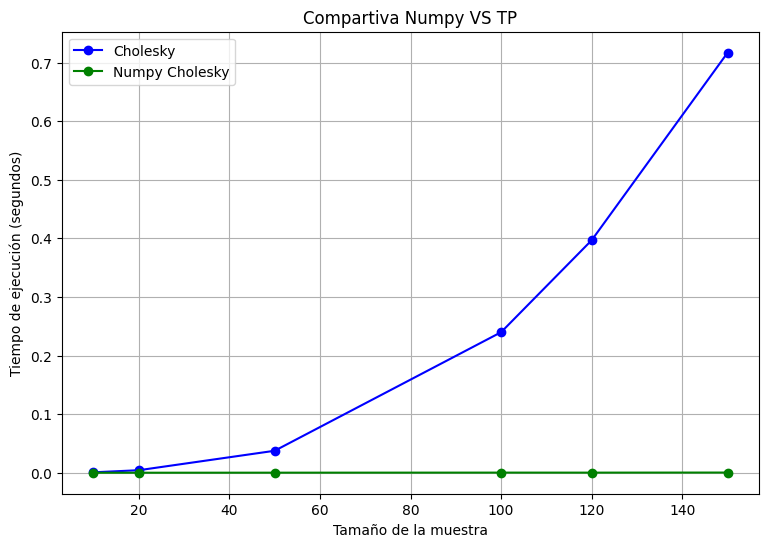

In [41]:
plt.figure(figsize=(9,6))

plt.plot(tam_muestra, t_ejecucion_CH, marker='o', label='Cholesky', color='blue')
plt.plot(tam_muestra, np_ejecucion_CH, marker='o', label='Numpy Cholesky', color='green')

plt.title("Compartiva Numpy VS TP")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.legend()
plt.grid(True)

plt.show()

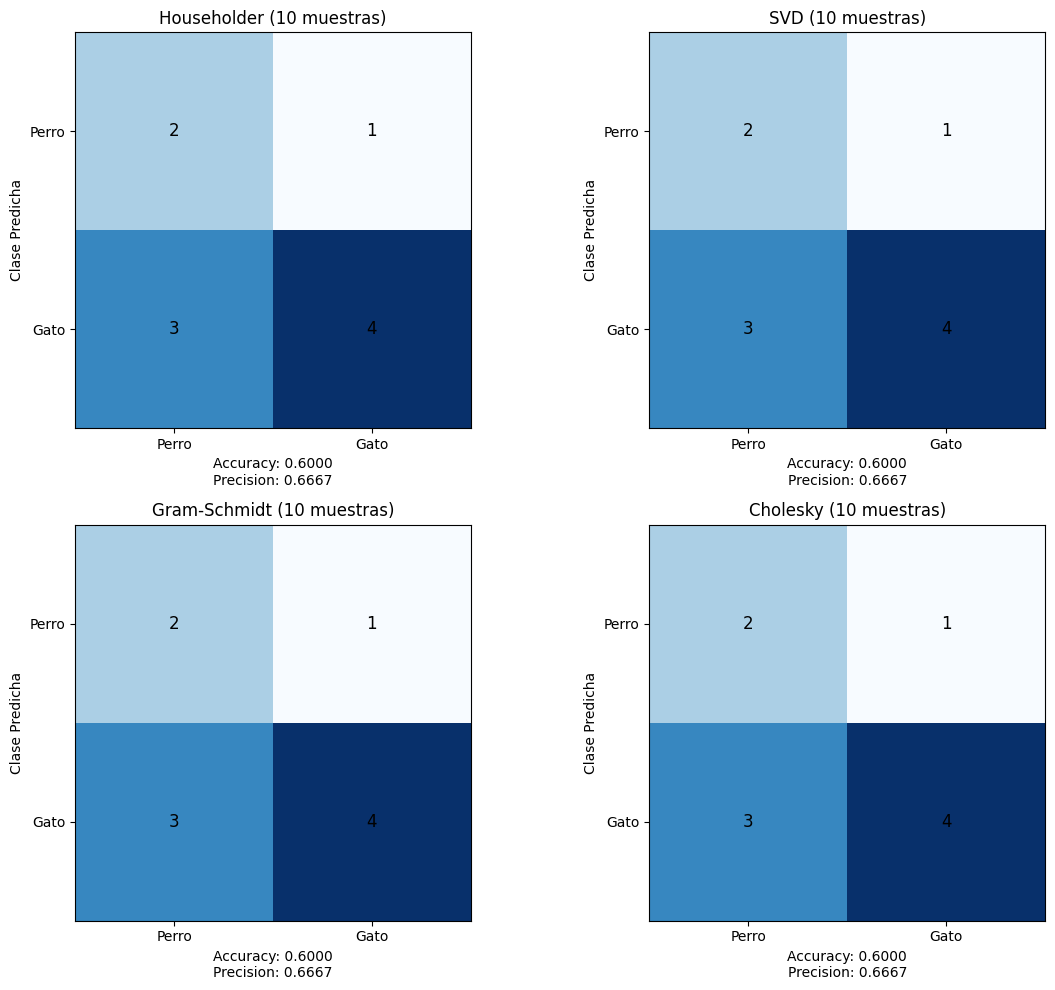

In [42]:
# Matriz de confusión para el tamaño de muestra más chico

N_menor = total_matriz[0]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()   # lo pasamos a vector: [0,1,2,3]

for x in range(len(N_menor)):
    plot_confusion_matrix(
        N_menor[x][0],  # matriz_conf
        N_menor[x][1],  # accuracy
        N_menor[x][2],  # precision
        N_menor[x][3],  # metodo_W
        N_menor[x][4],  # n
        axs[x]          # 👈 subplot correspondiente
    )

plt.tight_layout()
plt.show()

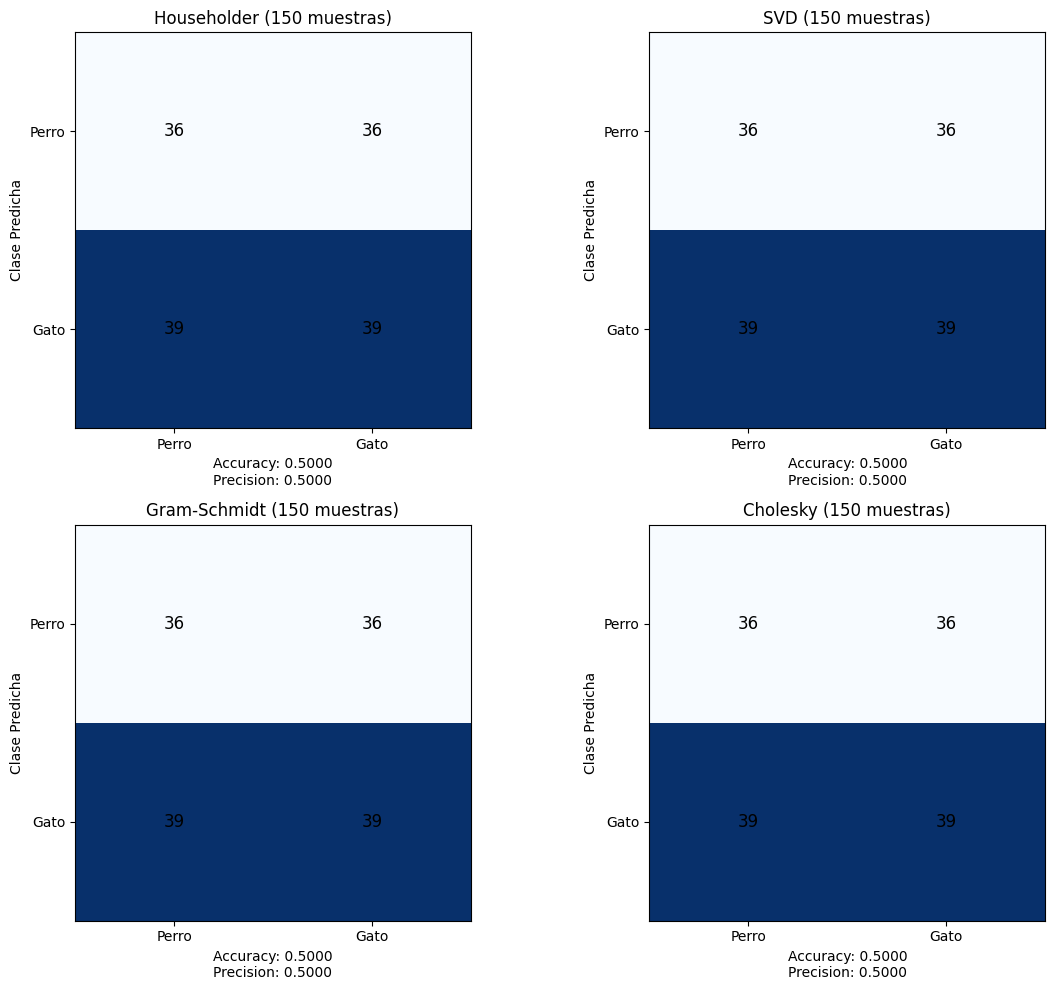

In [43]:
# Matriz de confusión para el tamaño de muestra más chico
N_mayor=(total_matriz[-1])

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()   # lo pasamos a vector: [0,1,2,3]

for x in range(len(N_menor)):
    plot_confusion_matrix(
        N_mayor[x][0],  # matriz_conf
        N_mayor[x][1],  # accuracy
        N_mayor[x][2],  # precision
        N_mayor[x][3],  # metodo_W
        N_mayor[x][4],  # n
        axs[x]          # 👈 subplot correspondiente
    )

plt.tight_layout()
plt.show()

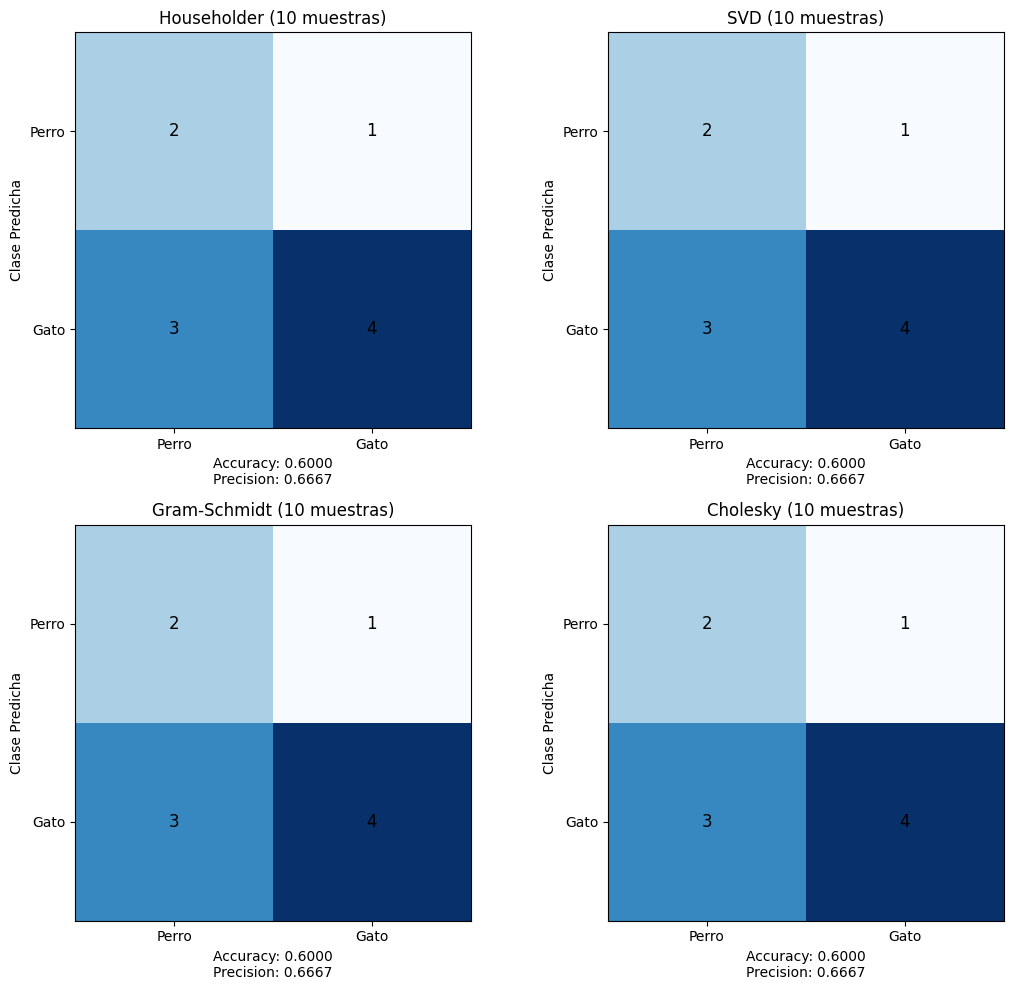

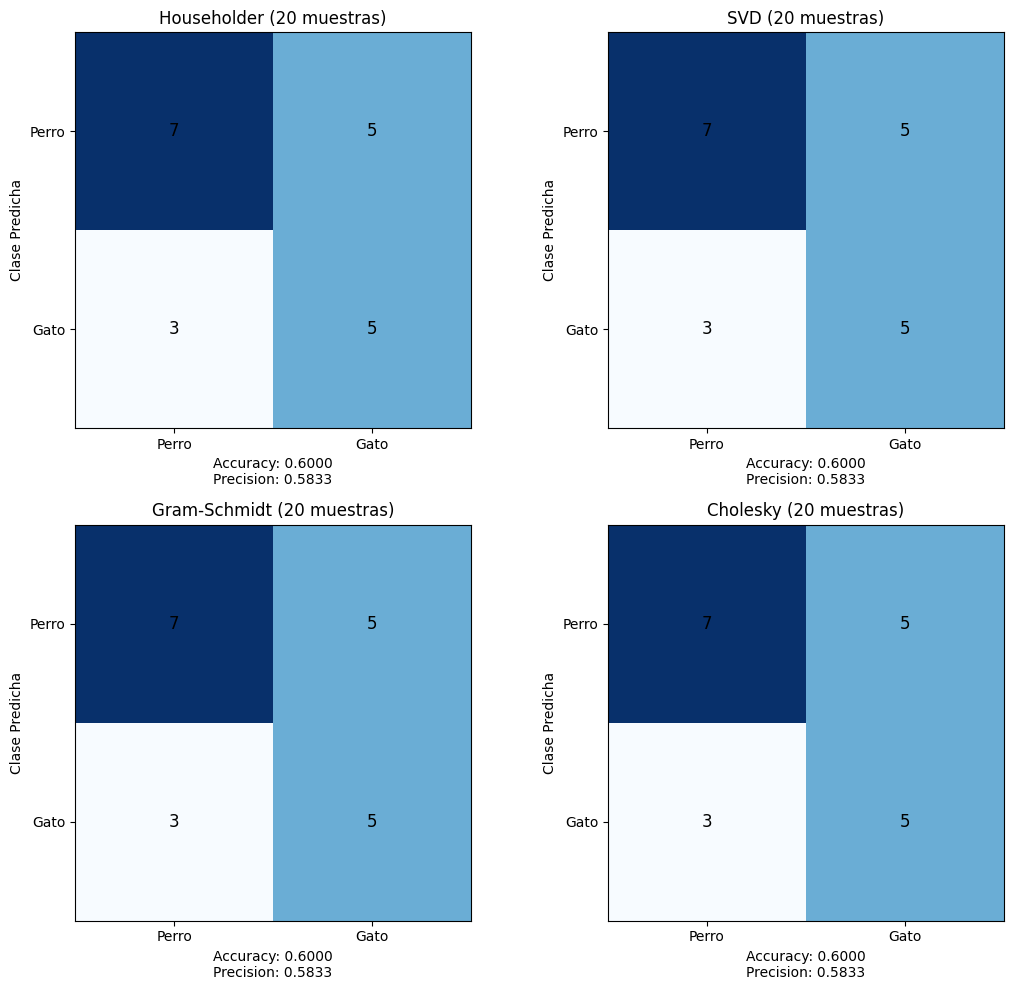

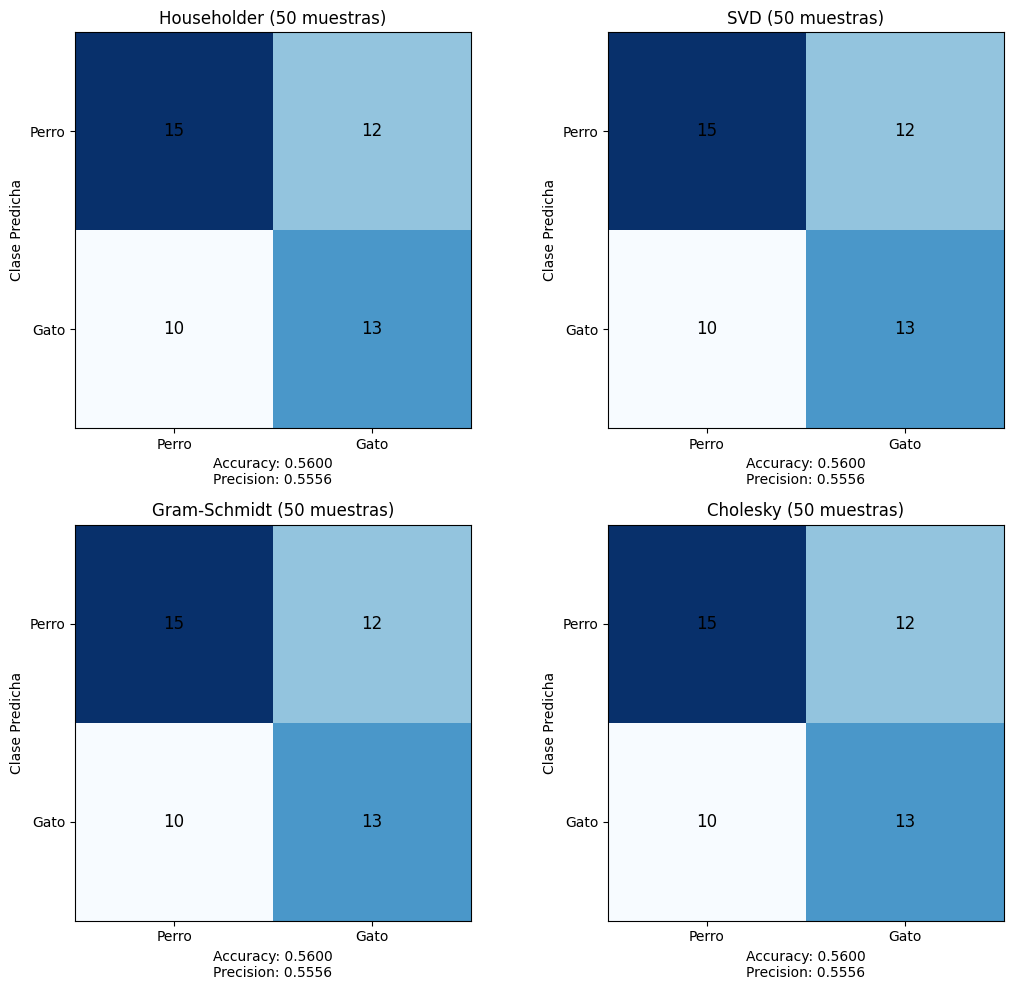

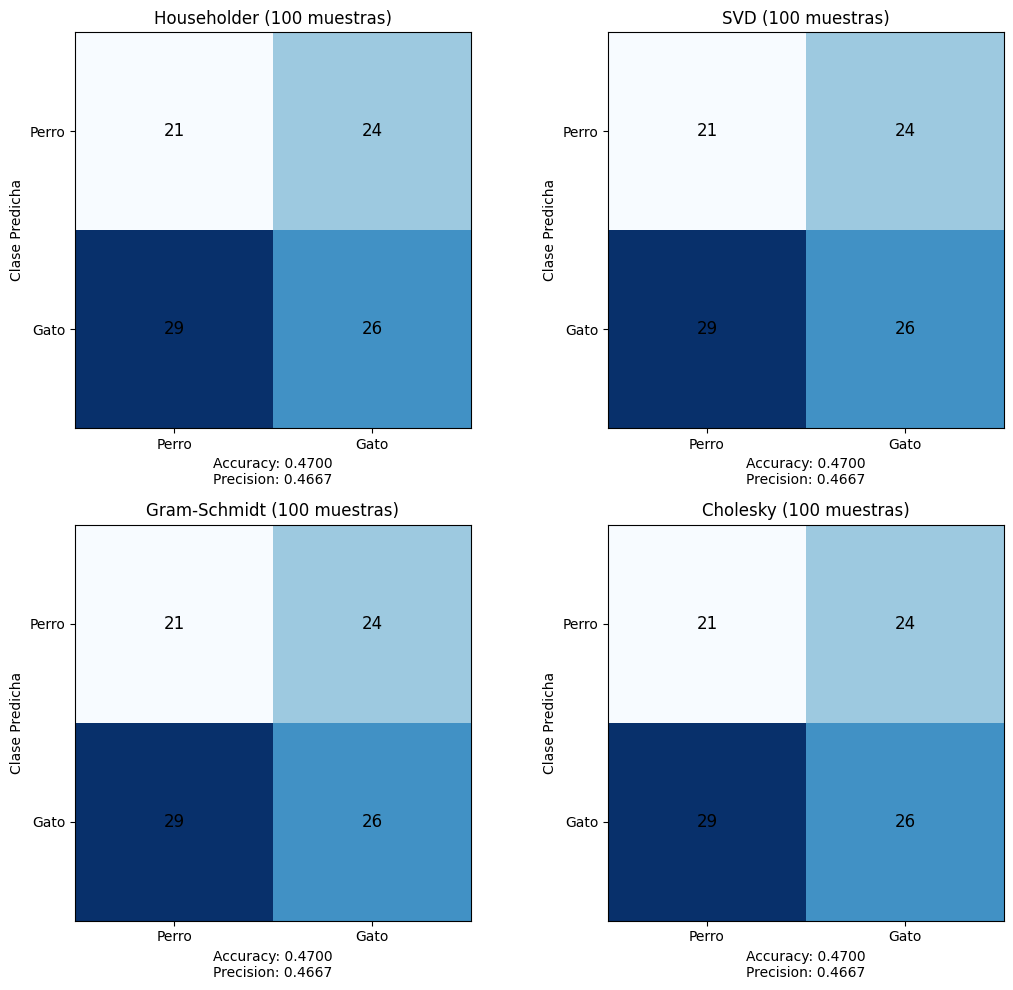

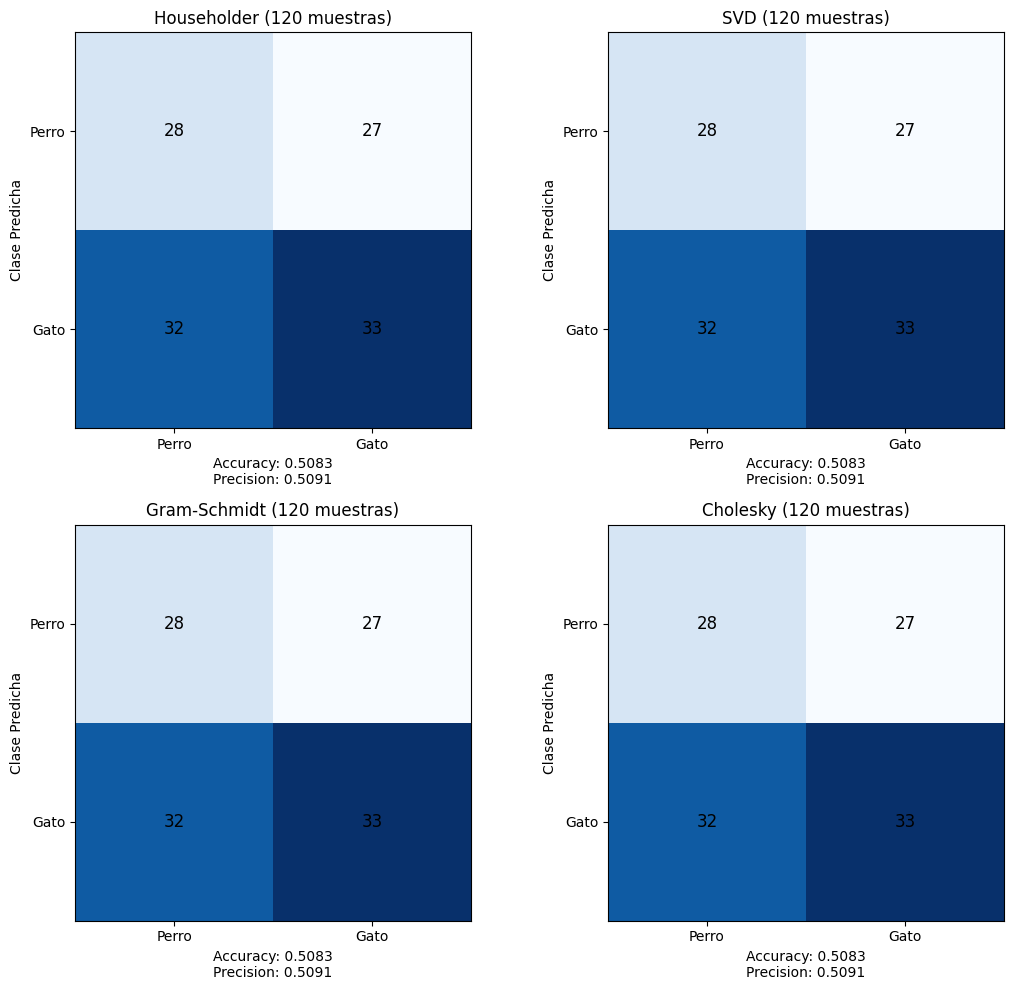

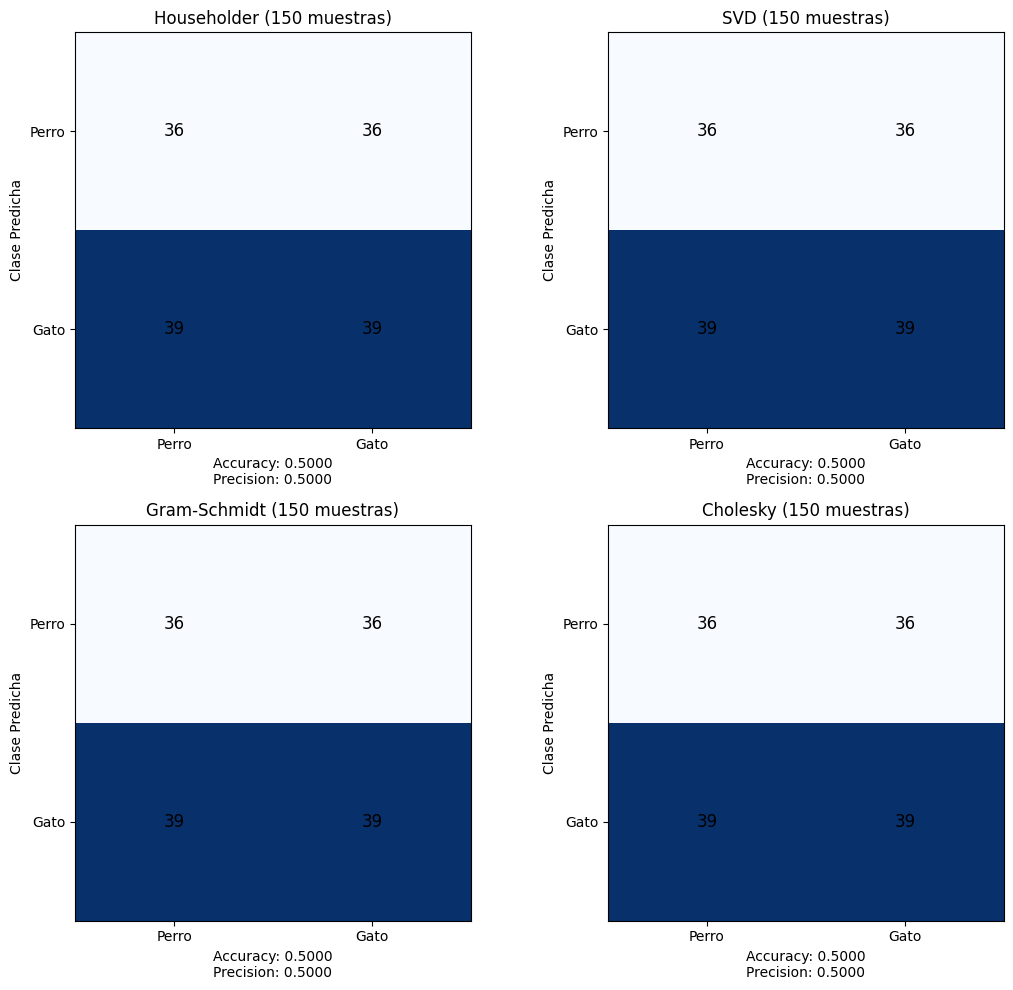

In [44]:
# Matriz de confusión por método para el total de la muestra

for k in range(0,len(total_matriz),1):
    tamaño_muestra=total_matriz[k]
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()   # lo pasamos a vector: [0,1,2,3]
    for x in range(0,len(tamaño_muestra),1):
        plot_confusion_matrix(tamaño_muestra[x][0], tamaño_muestra[x][1], tamaño_muestra[x][2], tamaño_muestra[x][3],tamaño_muestra[x][4],axs[x])
        plt.tight_layout()
    plt.show()

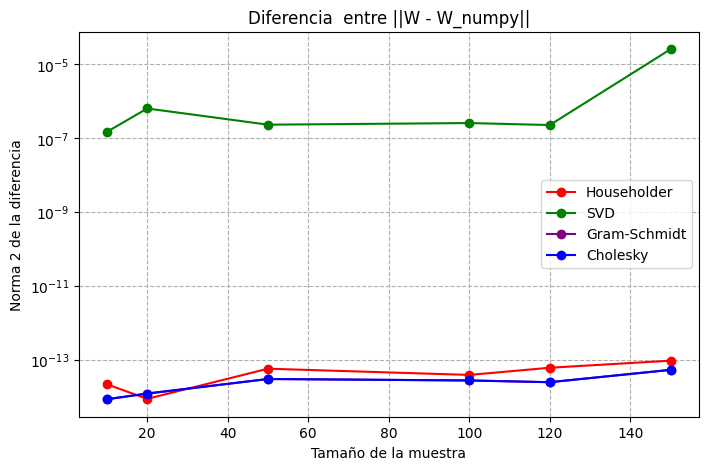

In [45]:



total_norma_C=[] #C= ||W - W_numpy||
dif_HH=[]
dif_SVD=[]
dif_GS=[]
dif_CH=[]
for x in range(0,len(total_dif_W),1):
    norma_C=[]
    for k in range(0,len(total_dif_W[x]),1):
        norma_C.append(np.linalg.norm(total_dif_W[x][k])) 
    total_norma_C.append(norma_C)

for i in range(0,len(tam_muestra),1):    
    dif_HH.append(total_norma_C[i][0])
    dif_SVD.append(total_norma_C[i][1])
    dif_GS.append(total_norma_C[i][2])
    dif_CH.append(total_norma_C[i][3])



#Diferencias entre métodos
plt.figure(figsize=(8,5))

plt.plot(tam_muestra, dif_HH, marker='o', label='Householder', color='red')
plt.plot(tam_muestra, dif_SVD, marker='o', label='SVD', color='green')
plt.plot(tam_muestra, dif_GS, marker='o', label='Gram-Schmidt', color='purple')
plt.plot(tam_muestra, dif_GS, marker='o', label='Cholesky', color='blue')

plt.yscale('log')   
plt.title("Diferencia  entre ||W - W_numpy||")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Norma 2 de la diferencia")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


In [46]:
tam_muestra2 =[200,350,500,1000]
datos_matriz_GS = []
for j in range(0,len(tam_muestra2),1):
    
    muestra=tam_muestra2[j]
    
    Xt=(muestraDeNelementos(Xt_o,muestra))
    Yt=(muestraDeNelementos_Y(Yt_o,muestra))
    Xv=(muestraDeNelementos(Xv_o,muestra))
    Yv=(muestraDeNelementos_Y(Yv_o,muestra))

    XtT = Xt.T
    p, n = XtT.shape  
    
    Q, R = QR_con_GS(XtT)
    W_GS_dos=pinvGramSchmidt(Q,R,Yt)
    
    matr_conf, acc, prec = GenerarMatrizDeConfusion(W_GS_dos, Xv,Yv)          
    matriz_GS=(matr_conf,acc,prec,'Gram-Schmidt',tam_muestra2[j])
    datos_matriz_GS.append(matriz_GS)

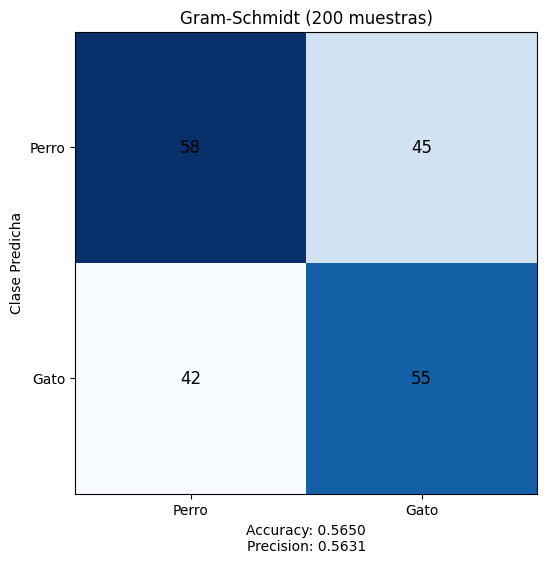

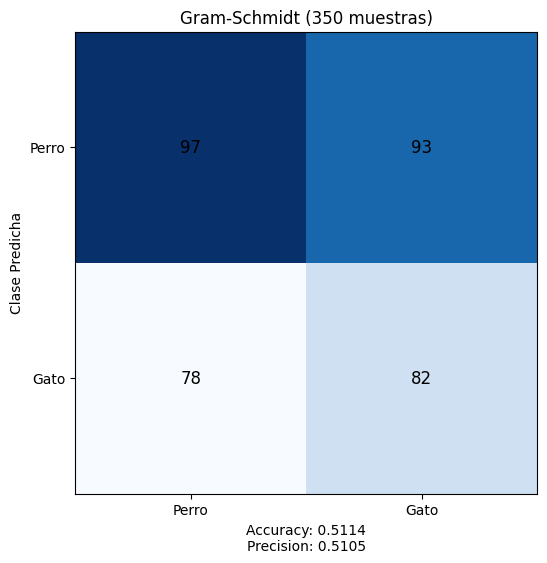

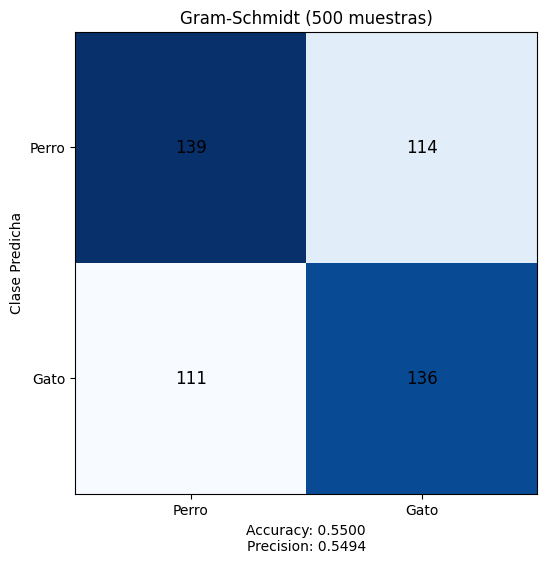

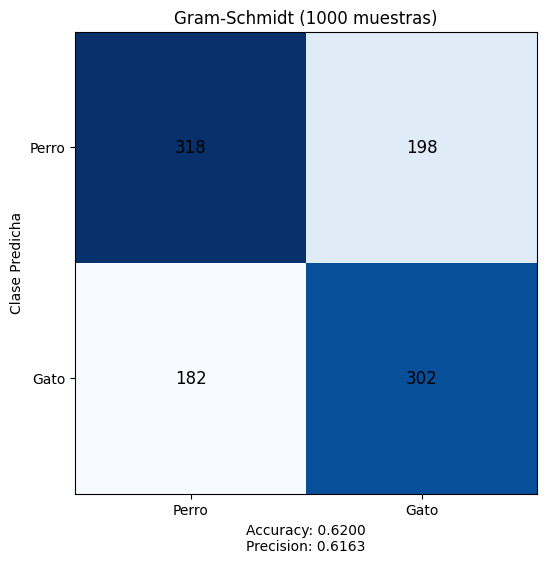

In [47]:
# Matriz de confusión por método para el total de la muestra

for k in range(0,len(datos_matriz_GS),1):
    fig, ax = plt.subplots(figsize=(8, 6))
    tamaño_muestra=datos_matriz_GS[k]
    plot_confusion_matrix(tamaño_muestra[0], tamaño_muestra[1], tamaño_muestra[2], tamaño_muestra[3],tamaño_muestra[4],ax)
    plt.show()



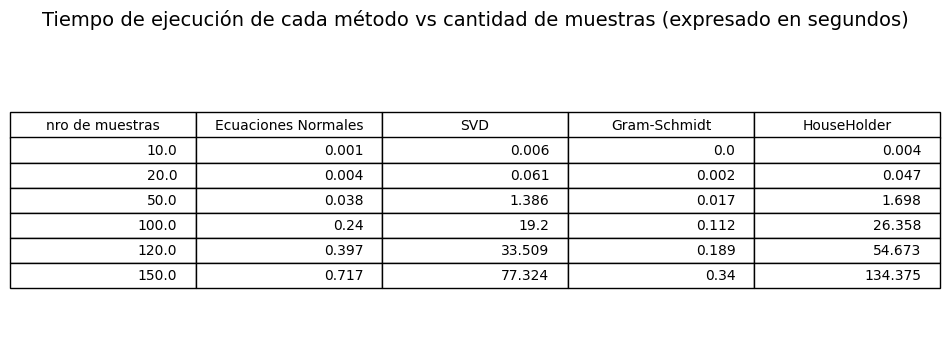

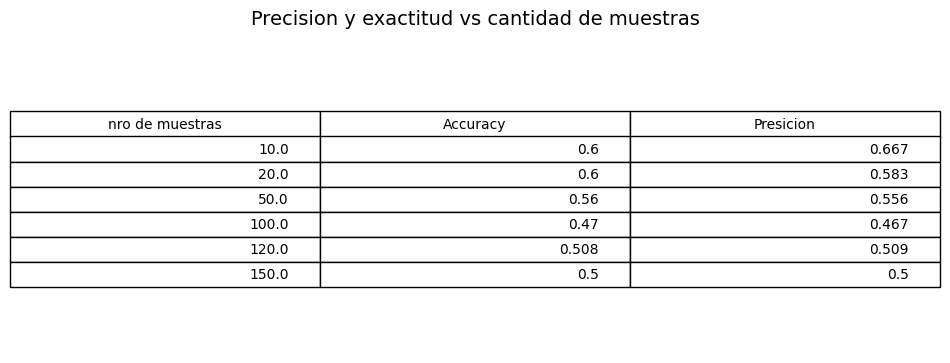

In [48]:
matriz_tiempos = np.zeros([len(tam_muestra),(len(metodos)+1)])
matriz_tiempos[:,0] = tam_muestra
matriz_tiempos[:,1] = t_ejecucion_CH
matriz_tiempos[:,2] = t_ejecucion_SVD
matriz_tiempos[:,3] = t_ejecucion_GS
matriz_tiempos[:,4] = t_ejecucion_HH

matriz_redondeada = np.round(matriz_tiempos,3)
tabla_mostrar = matriz_redondeada.copy()
tabla_mostrar[:,0] = tabla_mostrar[:,0].astype(int)

# Nombres de columnas
columnas = [
    "nro de muestras",
    "Ecuaciones Normales",
    "SVD",
    "Gram-Schmidt",
    "HouseHolder"
]

# Crear figura
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# Crear tabla
tabla = ax.table(
    cellText=tabla_mostrar,
    colLabels=columnas,
    loc="center"
)

# Ajustes visuales
tabla.scale(1, 1.5)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)

# Título
plt.title("Tiempo de ejecución de cada método vs cantidad de muestras (expresado en segundos)", fontsize=14, pad=15)

plt.show()
plt.close()

matriz_metricas = np.zeros((len(tam_muestra),3))
matriz_metricas[:,0] = tam_muestra
for nro in range(len(total_matriz)):
    matriz_metricas[nro][1] = total_matriz[nro][0][1]
    matriz_metricas[nro][2] = total_matriz[nro][0][2]

matriz_metricas_redondeada = np.round(matriz_metricas,3)
tabla_mostrar = matriz_metricas_redondeada.copy()
tabla_mostrar[:,0] = tabla_mostrar[:,0].astype(int)

# Nombres de columnas
columnas = [
    "nro de muestras",
    "Accuracy",
    "Presicion",
]

# Crear figura
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# Crear tabla
tabla = ax.table(
    cellText=tabla_mostrar,
    colLabels=columnas,
    loc="center"
)

# Ajustes visuales
tabla.scale(1, 1.5)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)

# Título
plt.title("Precision y exactitud vs cantidad de muestras", fontsize=14, pad=15)

plt.show()
plt.close()

Conclusión: El objetivo de este trabajo era comparar distintos métodos para categorizar imágenes de gatos y perros. Los métodos utilizados fueron ecuaciones normales (Cholesky), 
SVD, QR con Gram Schmidt y QR con HouseHolder. Utilizando cada uno de ellos, se calculó la pseudoinversa de distintos segmentos de la matriz de entrenamiento, y se evaluó la exactitud y precisión de cada uno de ellos. 

Según los resultados obtenidos, podemos concluir que los métodos de ecuaciones normales y Gram-Schmidt son los de menor complejidad temporal (en particular, Gram Schmidt), dado que sus tiempos de ejecución resultaron mucho menores que SVD y Householder.

Por otro lado, comparando las matrices de confusión de cada método se puede ver que, para un mismo número de muestras, todos los métodos retornan la misma matriz. Esto es esperable,
ya que en cada método se calcula la pseudoinversa de la matriz de entrenamiento, y sabemos que la pseudoinversa de una matriz es única.

En relación a las exactitudes y precisiones obtenidas, no se observó una clara relación entre el tamaño de las muestras y las métricas resultantes. Se observaron instancias en las que aumentar el tamaño de la muestra resultó en una disminución tanto de la exactitud como de la precisión. Esto podría deberse a que se tomó una muestras pequeñas para que los tiempos de ejecución no sean demasiado lentos. También podría deberse a la forma de seleccionar los datos de entrenamiento, los criterios utilizados fueron los siguientes: 
Por un lado, el método de HouseHolder solo admite matrices que tengan un número de filas mayor al de columnas. A su vez, para obtener los pesos W por este método es necesario transponer la matriz de entrenamiento Xt, la cual tiene un número de columnas mayor que al de filas, lo que hace que su transpuesta cumpla con el requisito susodicho para este método. Entonces, para mantener esta relación a la hora de tomar las muestras de n elementos de la matriz Xt para los experimentos, se optó por que la dimensiones de las mismas tengan una relación de n*0.76 para el número de filas por n  para el número de columnas.

Por otro lado, se buscó tomar siempre las primeras y las últimas columnas de la matriz de entrenamiento para asegurarnos de tener en cuenta tanto la información de las imagenes de perros como las de gatos. Pero al no haber considerado columnas aleatorias, tal vez no haya demasiada variedad en los datos para enriquecer al sistema.